# LabRack Vision QA — 02 Full Pipeline Demo

This notebook is my record of the system I actually built: select and validate a staged dataset, optionally train and evaluate YOLO11, run one image through the reusable project pipeline, and inspect the annotated image, JSON, and QA summary.

**Contribution roles:** I handled the programming, debugging, model training, evaluation, and technical deliverables. Kate Leemann collected the staged laboratory photos, completed the image annotations, and assisted me in designing the testing methodology.

> Educational prototype only. Not validated for clinical, diagnostic, or production laboratory use. Every finding is a possible issue requiring human review.

**Execution record:** I executed this notebook end to end on the Apple M3 Pro with PyTorch MPS. The CLI runbook documents the equivalent Ubuntu/RTX 4090 commands.

## 1. Find the repository

I want the notebook to work whether I start Jupyter from the repository root or from the `notebooks/` folder. I resolve the root once, then use explicit paths for the rest of the notebook.

In [1]:
from pathlib import Path
import os

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "src").is_dir():
    raise RuntimeError("Start Jupyter from the labrack-vision-qa repository.")

os.chdir(REPO_ROOT)
print("Repository:", REPO_ROOT)

Repository: /Users/Roderick/Downloads/GH/labrack-vision-qa


## 2. Confirm the software and accelerator

This check prevents me from assuming a GPU is being used. I use CUDA on the RTX 4090 and MPS on the M3 Pro, then record which accelerator produced each result.

In [2]:
import cv2
import matplotlib.pyplot as plt
import torch
import ultralytics

print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("MPS available:", torch.backends.mps.is_available())

PyTorch: 2.13.0
Ultralytics: 8.4.111
OpenCV: 5.0.0
CUDA available: False
MPS available: True


## 3. Select a dataset version

I do not hard-code a single future dataset into the notebook. `LABRACK_DATASET_YAML` lets me point the same pipeline at a newer reviewed export while keeping the current measured dataset intact.

Examples:

```bash
export LABRACK_DATASET_YAML=data/dataset.yaml
export LABRACK_DATASET_YAML=data/versions/2026-08-15/dataset.yaml
```

In [3]:
import yaml

DATASET_YAML = Path(
    os.environ.get("LABRACK_DATASET_YAML", "data/dataset.yaml")
).resolve()

if not DATASET_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {DATASET_YAML}")

with DATASET_YAML.open("r", encoding="utf-8") as handle:
    dataset_spec = yaml.safe_load(handle)

print("Dataset YAML:", DATASET_YAML)
print("Classes:", dataset_spec["names"])

Dataset YAML: /Users/Roderick/Downloads/GH/labrack-vision-qa/data/dataset.yaml
Classes: {0: 'rack', 1: 'tube', 2: 'cap', 3: 'empty_slot'}


## 4. Validate image/label pairs and YOLO boxes

This is my preflight before training. I check all three splits, the four-class schema, matching filenames, five-column YOLO detection rows, normalized coordinates, and exact duplicate boxes. A successful check does not prove every annotation is correct, so I still inspect images visually.

In [4]:
from collections import Counter

EXPECTED_NAMES = ["rack", "tube", "cap", "empty_slot"]
names = dataset_spec["names"]
if isinstance(names, dict):
    names = [names.get(i, names.get(str(i))) for i in range(len(names))]
if names != EXPECTED_NAMES:
    raise ValueError(f"Expected {EXPECTED_NAMES}, found {names}")

dataset_root = Path(dataset_spec.get("path", DATASET_YAML.parent))
if not dataset_root.is_absolute():
    dataset_root = REPO_ROOT / dataset_root

image_extensions = (".jpg", ".jpeg", ".png")
dataset_counts = {}
class_counts = Counter()
issues = []

for split in ("train", "val", "test"):
    image_dir = dataset_root / dataset_spec[split]
    label_dir = dataset_root / "labels" / split
    images = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in image_extensions)
    labels = sorted(label_dir.glob("*.txt"))
    image_by_stem = {p.stem: p for p in images}
    label_by_stem = {p.stem: p for p in labels}

    for stem in sorted(set(image_by_stem) ^ set(label_by_stem)):
        issues.append(f"{split}: unmatched image/label stem: {stem}")

    for label_path in labels:
        seen = set()
        for line_number, line in enumerate(label_path.read_text().splitlines(), start=1):
            fields = line.split()
            if len(fields) != 5:
                issues.append(f"{label_path}:{line_number}: expected 5 fields")
                continue
            class_id = int(fields[0])
            coords = tuple(float(value) for value in fields[1:])
            if class_id not in range(4):
                issues.append(f"{label_path}:{line_number}: invalid class {class_id}")
            if not all(0.0 <= value <= 1.0 for value in coords):
                issues.append(f"{label_path}:{line_number}: coordinates outside 0–1")
            row = (class_id, *coords)
            if row in seen:
                issues.append(f"{label_path}:{line_number}: duplicate box")
            seen.add(row)
            class_counts[class_id] += 1

    dataset_counts[split] = len(images)

print("Images by split:", dataset_counts)
print("Instances:", {EXPECTED_NAMES[i]: class_counts[i] for i in range(4)})
if issues:
    print("Problems found:")
    for issue in issues[:25]:
        print(" -", issue)
    raise ValueError(f"Dataset validation found {len(issues)} issue(s).")
print("Dataset structure and YOLO rows passed validation.")

Images by split: {'train': 125, 'val': 5, 'test': 10}
Instances: {'rack': 133, 'tube': 0, 'cap': 7391, 'empty_slot': 3339}
Dataset structure and YOLO rows passed validation.


## 5. Preview a labeled image

Numbers alone will not catch a box around the wrong object. I draw the saved ground-truth boxes over one test image so I can check placement, completeness, and class consistency.

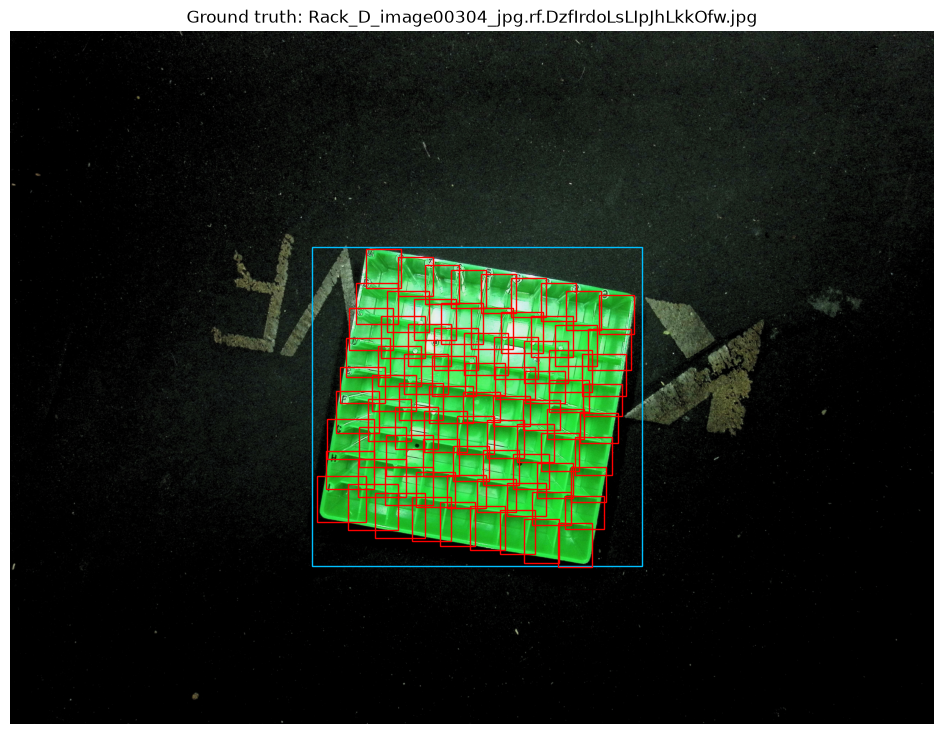

In [5]:
from matplotlib.patches import Rectangle

test_image_dir = dataset_root / dataset_spec["test"]
preview_image = sorted(
    p for p in test_image_dir.iterdir() if p.suffix.lower() in image_extensions
)[0]
preview_label = dataset_root / "labels" / "test" / f"{preview_image.stem}.txt"

image_bgr = cv2.imread(str(preview_image))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]
colors = {0: "deepskyblue", 1: "lime", 2: "orange", 3: "red"}

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image_rgb)
for row in preview_label.read_text().splitlines():
    class_id, cx, cy, box_w, box_h = map(float, row.split())
    class_id = int(class_id)
    x = (cx - box_w / 2) * width
    y = (cy - box_h / 2) * height
    ax.add_patch(Rectangle(
        (x, y), box_w * width, box_h * height,
        fill=False, linewidth=1, edgecolor=colors[class_id]
    ))
ax.set_title(f"Ground truth: {preview_image.name}")
ax.axis("off")
plt.show()

## 6. Future optional RTX 4090 training matrix

I keep future training behind a switch because my current M3 version is complete and I do not want to start six long runs while recording the short demo. After the next reviewed dataset version is available, I will use this cell on my Ubuntu RTX 4090 system to launch the reusable script documented in my CLI runbook. I will train YOLO11n, YOLO11s, and YOLO11m at both 640 and 960 pixels, validate every candidate, apply my predeclared selection rule, and create a verified evidence ZIP before I update the repository.

For that future version, I will not use the current Apple M3 LabRack checkpoint as a starting weight. I will use the official COCO-pretrained YOLO11 checkpoints and begin each candidate as a fresh fine-tune from the official base for its model size.

In [6]:
import subprocess
import sys

RUN_TRAINING = False
RTX4090_RUN_ID = os.environ.get("LABRACK_4090_RUN_ID", "final_rtx4090")
RTX4090_OUTPUT_ROOT = Path(
    os.environ.get("LABRACK_4090_OUTPUT", REPO_ROOT.parent / "labrack-4090-output")
).resolve()

if RUN_TRAINING:
    if not torch.cuda.is_available() or "4090" not in torch.cuda.get_device_name(0):
        raise RuntimeError("My future matrix requires the Ubuntu RTX 4090 system.")
    subprocess.run(
        [
            sys.executable,
            str(REPO_ROOT / "scripts" / "run_rtx4090_matrix.py"),
            "--data", str(DATASET_YAML),
            "--output-root", str(RTX4090_OUTPUT_ROOT),
            "--run-id", RTX4090_RUN_ID,
        ],
        cwd=REPO_ROOT,
        check=True,
    )
else:
    print("Training skipped. Set RUN_TRAINING=True when I intend to train.")

Training skipped. Set RUN_TRAINING=True when I intend to train.


## 7. Optional held-out evaluation

Validation is for choosing a model. I run the final test only after the configuration is fixed. Rack_D has already informed the current improvement plan, so the next final report needs a newly collected, untouched rack group.

In [7]:
MODEL_PATH = Path(
    os.environ.get("LABRACK_MODEL_PATH", "weights/labrack_yolo11s_960.pt")
).resolve()
RUN_EVALUATION = False

if RUN_EVALUATION:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Model weights not found: {MODEL_PATH}")
    evaluation_model = YOLO(str(MODEL_PATH))
    evaluation_model.val(
        data=str(DATASET_YAML),
        split="test",
        imgsz=960,
        device=0 if torch.cuda.is_available() else "mps",
        workers=8 if torch.cuda.is_available() else 0,
        project=str(REPO_ROOT / "runs"),
        name="selected_yolo11s_960_test",
        exist_ok=True,
        plots=True,
    )
else:
    print("Evaluation skipped. Set RUN_EVALUATION=True for a deliberate test run.")

Evaluation skipped. Set RUN_EVALUATION=True for a deliberate test run.


## 8. Run the complete application pipeline

This is the code path I demonstrate. I call `process_image` from `src.run` instead of copying application logic into the notebook. That keeps the notebook and CLI consistent: validate → detect → QA rules → annotated image + JSON + summary.

LabRack Vision QA — Summary
Image:  Rack_D_image00304_jpg.rf.DzfIrdoLsLIpJhLkkOfw.jpg
Model:  /Users/Roderick/Downloads/GH/labrack-vision-qa/weights/labrack_yolo11s_960.pt
Time:   0.974 s

Counts (core classes):
  rack         1
  tube         0
  cap          1
  empty_slot   7

QA flags:
  [REVIEW] 7 possible empty position(s) detected — requires human review.
  [REVIEW] 8 detection(s) below the 0.50 confidence threshold — manual review recommended.

Manual review recommended.

Educational prototype only. Not validated for clinical, diagnostic, or production laboratory use. Human review is required.


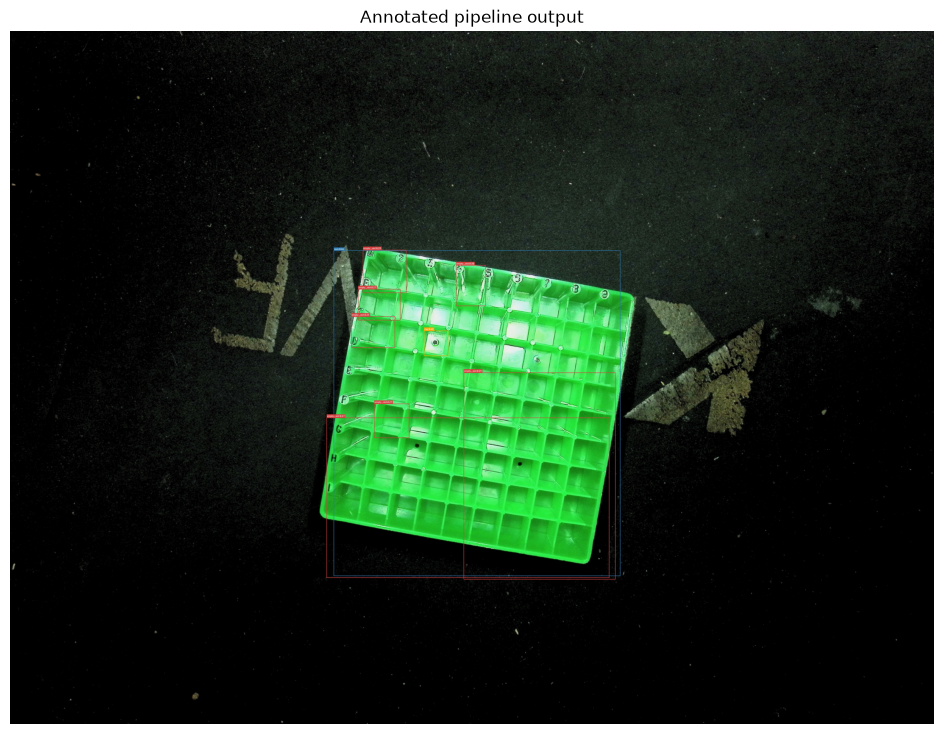

In [8]:
from src.run import process_image

DEMO_IMAGE = Path(os.environ.get(
    "LABRACK_DEMO_IMAGE",
    "data/images/test/Rack_D_image00304_jpg.rf.DzfIrdoLsLIpJhLkkOfw.jpg",
)).resolve()
DEMO_OUTPUT = REPO_ROOT / "output" / "notebook_demo"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing {MODEL_PATH}. Train a model or set LABRACK_MODEL_PATH."
    )

results, summary_text, output_paths = process_image(
    DEMO_IMAGE,
    output_dir=DEMO_OUTPUT,
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    image_size=960,
)

print(summary_text)
annotated_bgr = cv2.imread(str(output_paths["annotated"]))
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 9))
plt.imshow(annotated_rgb)
plt.title("Annotated pipeline output")
plt.axis("off")
plt.show()

## 9. Inspect the structured result

The JSON keeps the model path, image size, counts, every box and confidence, review flags, timing, and disclaimer. This is useful for validation because I can trace the summary back to individual detections.

In [9]:
import json

print(json.dumps({
    "model": results["model"],
    "image_size": results["image_size"],
    "inference_image_size": results["inference_image_size"],
    "core_counts": results["core_counts"],
    "flags": results["flags"],
    "review_recommended": results["review_recommended"],
    "inference_seconds": results["inference_seconds"],
    "disclaimer": results["disclaimer"],
}, indent=2))
print("Full JSON:", output_paths["json"])
print("Text summary:", output_paths["summary"])

{
  "model": "/Users/Roderick/Downloads/GH/labrack-vision-qa/weights/labrack_yolo11s_960.pt",
  "image_size": [
    5696,
    4272
  ],
  "inference_image_size": 960,
  "core_counts": {
    "rack": 1,
    "tube": 0,
    "cap": 1,
    "empty_slot": 7
  },
  "flags": [
    {
      "level": "review",
      "message": "7 possible empty position(s) detected \u2014 requires human review."
    },
    {
      "level": "review",
      "message": "8 detection(s) below the 0.50 confidence threshold \u2014 manual review recommended."
    }
  ],
  "review_recommended": true,
  "inference_seconds": 0.974,
  "disclaimer": "Educational prototype only. Not validated for clinical, diagnostic, or production laboratory use. Human review is required."
}
Full JSON: /Users/Roderick/Downloads/GH/labrack-vision-qa/output/notebook_demo/Rack_D_image00304_jpg.rf.DzfIrdoLsLIpJhLkkOfw_results.json
Text summary: /Users/Roderick/Downloads/GH/labrack-vision-qa/output/notebook_demo/Rack_D_image00304_jpg.rf.DzfIrdoLsLIp

## 10. Compare the measured validation and diagnostic results

I load the checked-in M3 metric tables rather than typing scores into the notebook. I use validation to select the current model. I show Rack_D separately as diagnostic evidence because it already informed this iteration. When I complete a future RTX 4090 dataset version, I will update these files only from a verified evidence package.

In [10]:
import csv

comparison_path = REPO_ROOT / "results" / "metrics" / "candidate_comparison.csv"
with comparison_path.open(newline="", encoding="utf-8") as handle:
    candidate_rows = list(csv.DictReader(handle))

print("Validation candidate progression")
print(f"{'model':<10} {'imgsz':>7} {'mAP50':>10} {'mAP50-95':>10} {'empty recall':>13}")
for row in candidate_rows:
    marker = "*" if row["selected"] == "yes" else " "
    print(
        f"{marker}{row['model']:<9} {row['image_size']:>7} "
        f"{row['validation_map50']:>10} {row['validation_map50_95']:>10} "
        f"{row['empty_slot_recall']:>13}"
    )

metric_files = {
    "Rack_C validation": REPO_ROOT / "results" / "metrics" / "selected_validation_metrics.csv",
    "Rack_D diagnostic": REPO_ROOT / "results" / "metrics" / "held_out_test_metrics.csv",
}

for label, metrics_path in metric_files.items():
    with metrics_path.open(newline="", encoding="utf-8") as handle:
        metric_rows = list(csv.DictReader(handle))
    print(f"\n{label}")
    print(f"{'class':<14} {'precision':>10} {'recall':>10} {'mAP50':>10} {'mAP50-95':>10}")
    for row in metric_rows:
        print(
            f"{row['class']:<14} {row['precision']:>10} {row['recall']:>10} "
            f"{row['map50']:>10} {row['map50_95']:>10}"
        )

print("\nBlueprint target: aggregate mAP50 >= 0.75 for trained classes")
print("Selected validation: mAP50 0.825; empty-slot recall 0.858")
print("Rack_D diagnostic: mAP50 0.937; empty-slot recall 0.761")

Validation candidate progression
model        imgsz      mAP50   mAP50-95  empty recall
 YOLO11n       640      0.729      0.503         0.428
 YOLO11n       960      0.809      0.539         0.470
 YOLO11s       640      0.761      0.552         0.404
*YOLO11s       960      0.825      0.594         0.858
 YOLO11m       640      0.730      0.520         0.381

Rack_C validation
class           precision     recall      mAP50   mAP50-95
all                 0.799      0.898      0.825      0.594
rack                0.872      1.000      0.995      0.876
cap                 0.716      0.837      0.663      0.503
empty_slot          0.807      0.858      0.817      0.405
tube                                                      

Rack_D diagnostic
class           precision     recall      mAP50   mAP50-95
all                 0.899      0.918      0.937      0.601
rack                0.923      1.000      0.995      0.765
cap                 0.934      0.992      0.977      0.692
empty_slo

## 11. What the retraining fixed—and what it did not

I improved validation empty-slot recall from 0.428 for the YOLO11n/640 baseline to 0.858 for YOLO11s/960 through the controlled comparison. I also increased the Rack_D diagnostic empty-slot recall from 0.327 to 0.761.

I intentionally use a difficult default demo image. Kate's annotation has 81 empty slots and no caps, while my selected model reports seven possible empty positions and one cap. I describe that as a possible issue requiring human review, not a reliable inspection result.

The remaining limitations are concrete: only five validation images, one diagnostic rack group, no new pristine physical-rack test group, and zero tube instances. The RTX 4090 can make the same experiments faster, but hardware alone does not repair data or guarantee better accuracy.

## 12. Updating the dataset safely

I keep each reviewed export under `data/versions/<version>/` with its own YAML. I preserve the untouched Roboflow export under `data/source/<version>/`, split by physical rack, and set `LABRACK_DATASET_YAML` before reopening this notebook. This lets me rerun the same validation, training, evaluation, and inference cells without rewriting the pipeline.

I never overwrite reported metrics until the new version passes validation and a real held-out evaluation finishes. I never auto-label the final test set, and I inspect all images for staged materials and the absence of patient information.